# Audio EQ Single-Measurement Calibration
A clean, standalone notebook for room acoustic measurement and parametric EQ correction.

In [13]:
!pip install numpy scipy matplotlib sounddevice


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports & Configuration

In [14]:
import numpy as np
import scipy.signal as signal
import scipy.fft as fft
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter1d
import sounddevice as sd
import warnings
warnings.filterwarnings('ignore')

SAMPLE_RATE = 48000
print(f"Sample Rate : {SAMPLE_RATE} Hz  |  Nyquist: {SAMPLE_RATE//2} Hz")
try:
    print(f"Default input  : {sd.query_devices(kind='input')['name']}")
    print(f"Default output : {sd.query_devices(kind='output')['name']}")
except Exception as e:
    print(f"Audio device query failed: {e}")

Sample Rate : 48000 Hz  |  Nyquist: 24000 Hz
Default input  : Microphone (Usb Audio Device)
Default output : DELL U2719D (NVIDIA High Defini


## 2. Log Sweep Generator

Sweep: 5.0s  |  240,000 samples


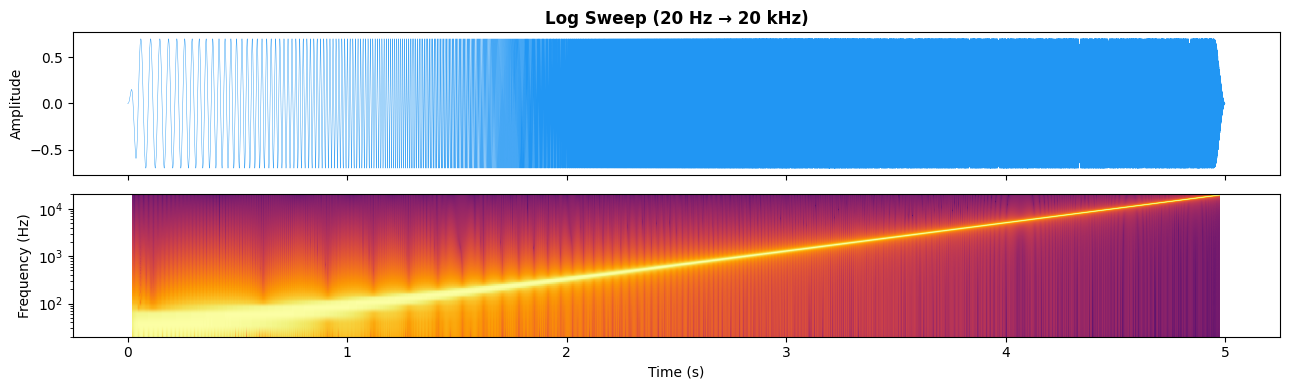

In [15]:
def make_log_sweep(duration=5.0, f_start=20.0, f_end=20000.0, amplitude=0.7, sr=SAMPLE_RATE):
    n = int(duration * sr)
    t = np.linspace(0, duration, n, endpoint=False)
    L = duration / np.log(f_end / f_start)
    sweep = amplitude * np.sin(2 * np.pi * f_start * L * (np.exp(t / L) - 1))
    fade = int(0.05 * sr)
    sweep[:fade] *= 0.5 * (1 - np.cos(np.pi * np.arange(fade) / fade))
    sweep[-fade:] *= 0.5 * (1 + np.cos(np.pi * np.arange(fade) / fade))
    inv = np.sin(2 * np.pi * f_start * L * (np.exp(t / L) - 1))
    inv = inv[::-1]
    inv *= np.exp(-t / L)
    inv /= np.max(np.abs(inv))
    return sweep, inv

sweep, inv_filter = make_log_sweep()
print(f"Sweep: {len(sweep)/SAMPLE_RATE:.1f}s  |  {len(sweep):,} samples")

fig, axes = plt.subplots(2, 1, figsize=(13, 4), sharex=True)
t = np.arange(len(sweep)) / SAMPLE_RATE
axes[0].plot(t, sweep, lw=0.3, color='#2196F3')
axes[0].set_ylabel('Amplitude'); axes[0].set_title('Log Sweep (20 Hz \u2192 20 kHz)', fontweight='bold')
axes[1].specgram(sweep, NFFT=2048, Fs=SAMPLE_RATE, noverlap=1900, cmap='inferno', scale='dB')
axes[1].set_yscale('log'); axes[1].set_ylim(20, 20000)
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Frequency (Hz)')
plt.tight_layout(); plt.show()

## 3. Play & Record (Live or Simulated)

▶ Playing & recording 7.0s ...
  ✅ Peak 0.414  (-7.7 dBFS)


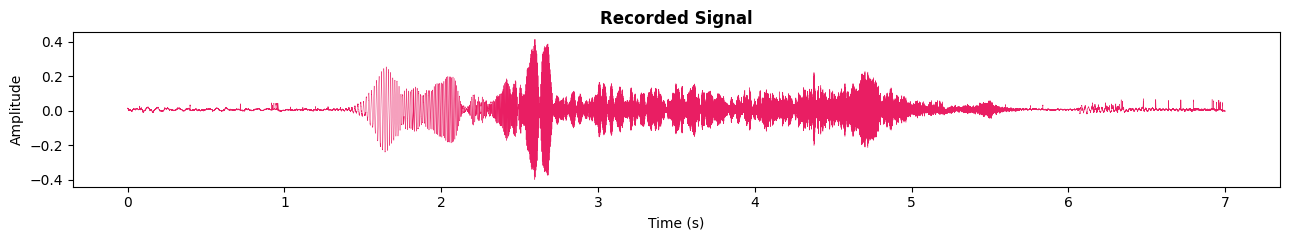

In [16]:
def play_and_record(stimulus, pre_silence=0.5, post_silence=1.5, sr=SAMPLE_RATE):
    pre = np.zeros(int(pre_silence * sr))
    post = np.zeros(int(post_silence * sr))
    padded = np.concatenate([pre, stimulus, post]).astype(np.float32)
    print(f"\u25b6 Playing & recording {len(padded)/sr:.1f}s ...")
    rec = sd.playrec(padded, samplerate=sr, channels=1)
    sd.wait()
    rec = rec.flatten()
    peak = np.max(np.abs(rec))
    if peak > 0.95:
        print(f"  \u26a0\ufe0f  Clipping risk \u2014 peak {peak:.3f}. Lower speaker volume.")
    else:
        print(f"  \u2705 Peak {peak:.3f}  ({20*np.log10(peak+1e-10):.1f} dBFS)")
    return rec

def simulate_room_response(stimulus, sr=SAMPLE_RATE, seed=0):
    """Synthetic room: bass mode at 65 Hz, dip at 250 Hz, presence dip, HF rolloff."""
    n = len(stimulus)
    X = fft.rfft(stimulus)
    freqs = fft.rfftfreq(n, 1.0/sr)
    freqs[0] = 0.1
    H = np.zeros(len(freqs))
    H += 8.0  * np.exp(-0.5 * ((np.log2(np.maximum(freqs,0.1)/65))   / (1/(2*3)))**2)
    H += 4.0  / (1 + (freqs/80)**2)
    H -= 6.0  * np.exp(-0.5 * ((np.log2(np.maximum(freqs,0.1)/250))  / (1/(2*5)))**2)
    H -= 4.0  * np.exp(-0.5 * ((np.log2(np.maximum(freqs,0.1)/3000)) / (1/(2*1.5)))**2)
    H += 3.0  * np.exp(-0.5 * ((np.log2(np.maximum(freqs,0.1)/6500)) / (1/(2*6)))**2)
    hf = freqs > 8000
    H[hf] -= 3.0 * np.log2(freqs[hf] / 8000)
    Y = X * 10**(H/20)
    y = fft.irfft(Y, n=n)
    rng = np.random.RandomState(seed)
    y += rng.randn(len(y)) * 0.001
    return y

# ---------- run ----------
USE_LIVE = True   # set True to use real microphone

if USE_LIVE:
    try:
        recorded = play_and_record(sweep)
    except Exception as e:
        print(f"Audio error: {e}\nFalling back to simulation.")
        USE_LIVE = False

if not USE_LIVE:
    print("\U0001f52c Using simulated room response.")
    pre = np.zeros(int(0.5*SAMPLE_RATE))
    post = np.zeros(int(1.5*SAMPLE_RATE))
    recorded = simulate_room_response(np.concatenate([pre, sweep, post]))

fig, ax = plt.subplots(figsize=(13, 2.5))
ax.plot(np.arange(len(recorded))/SAMPLE_RATE, recorded, lw=0.3, color='#E91E63')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude'); ax.set_title('Recorded Signal', fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Deconvolution → Impulse Response → Frequency Response

IR: 24480 samples (510 ms)  |  peak at 5719.7 ms


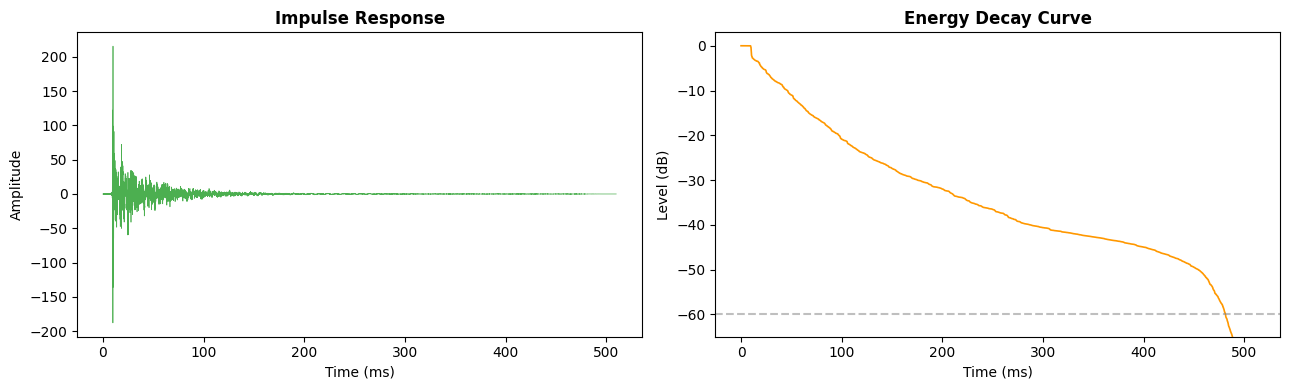

In [17]:
def extract_ir(recording, inv_filter, sr=SAMPLE_RATE):
    n_fft = int(2**np.ceil(np.log2(len(recording)+len(inv_filter)-1)))
    R = fft.rfft(recording, n=n_fft)
    I = fft.rfft(inv_filter, n=n_fft)
    ir_full = fft.irfft(R * I, n=n_fft)
    peak = np.argmax(np.abs(ir_full))
    start = max(0, peak - int(0.01*sr))
    end   = min(len(ir_full), peak + int(0.5*sr))
    ir = ir_full[start:end]
    fade = int(0.05*sr)
    win = np.ones(len(ir))
    win[-fade:] = 0.5*(1+np.cos(np.pi*np.arange(fade)/fade))
    ir *= win
    print(f"IR: {len(ir)} samples ({len(ir)/sr*1000:.0f} ms)  |  peak at {peak/sr*1000:.1f} ms")
    return ir

def compute_freq_response(ir, sr=SAMPLE_RATE, n_fft=16384):
    H = fft.rfft(ir, n=n_fft)
    freqs = fft.rfftfreq(n_fft, 1.0/sr)
    mag = 20*np.log10(np.abs(H)+1e-10)
    ref = mag[np.argmin(np.abs(freqs-1000))]
    return freqs, mag - ref

def smooth_third_octave(freqs, mag):
    sm = mag.copy()
    log_f = np.log2(freqs+1e-10)
    for i in range(len(freqs)):
        if freqs[i] < 10: continue
        mask = np.abs(log_f - log_f[i]) <= 1/6
        if mask.sum(): sm[i] = mag[mask].mean()
    return sm

ir = extract_ir(recorded, inv_filter)
freqs, raw_mag = compute_freq_response(ir)
smoothed = smooth_third_octave(freqs, raw_mag)

# Plot IR + EDC
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
t_ir = np.arange(len(ir))/SAMPLE_RATE*1000
axes[0].plot(t_ir, ir, lw=0.5, color='#4CAF50')
axes[0].set_xlabel('Time (ms)'); axes[0].set_ylabel('Amplitude'); axes[0].set_title('Impulse Response', fontweight='bold')

edc = 10*np.log10(np.cumsum(ir[::-1]**2)[::-1]+1e-10)
edc -= edc[0]
axes[1].plot(t_ir, edc, color='#FF9800', lw=1.2)
axes[1].set_ylim(-65, 3); axes[1].set_xlabel('Time (ms)'); axes[1].set_ylabel('Level (dB)')
axes[1].set_title('Energy Decay Curve', fontweight='bold'); axes[1].axhline(-60, color='gray', ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

## 5. Target Curve & Deviation

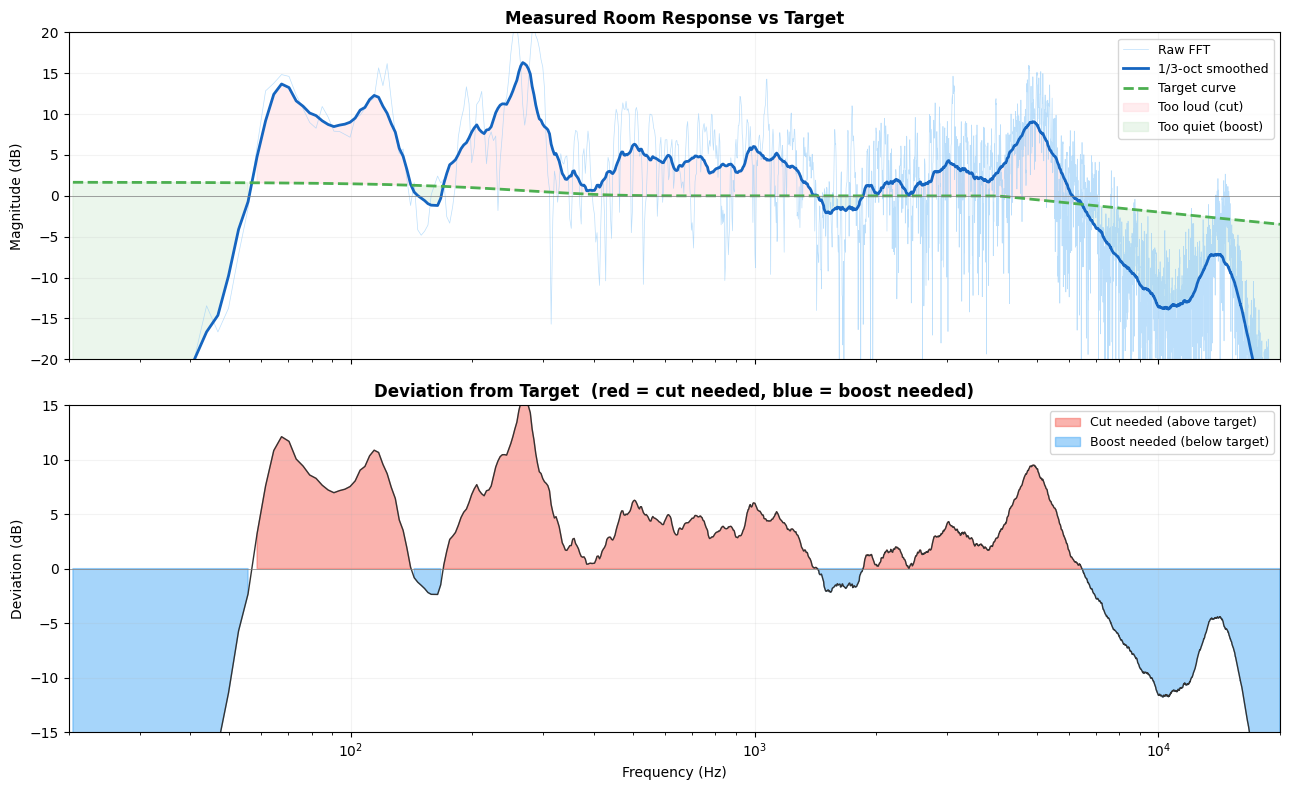

RMS deviation (50 Hz–12 kHz): 6.90 dB


In [18]:
def make_target(freqs):
    target = np.zeros_like(freqs)
    target[freqs < 200] = 2.0
    hf = freqs > 4000
    target[hf] = -1.5 * np.log2(freqs[hf]/4000)
    return gaussian_filter1d(target, sigma=50)

target = make_target(freqs)
deviation = smoothed - target   # positive = too loud (cut), negative = too quiet (boost)

mask = (freqs >= 20) & (freqs <= 20000)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

axes[0].plot(freqs[mask], raw_mag[mask],  color='#90CAF9', lw=0.5, alpha=0.6, label='Raw FFT')
axes[0].plot(freqs[mask], smoothed[mask], color='#1565C0', lw=2,   label='1/3-oct smoothed')
axes[0].plot(freqs[mask], target[mask],   color='#4CAF50', lw=2, ls='--', label='Target curve')
axes[0].fill_between(freqs[mask], smoothed[mask], target[mask],
    where=smoothed[mask]>target[mask], color='#FFCDD2', alpha=0.35, label='Too loud (cut)')
axes[0].fill_between(freqs[mask], smoothed[mask], target[mask],
    where=smoothed[mask]<target[mask], color='#C8E6C9', alpha=0.35, label='Too quiet (boost)')
axes[0].set_xscale('log'); axes[0].set_xlim(20,20000); axes[0].set_ylim(-20,20)
axes[0].set_ylabel('Magnitude (dB)')
axes[0].set_title('Measured Room Response vs Target', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.15); axes[0].axhline(0, color='gray', lw=0.5)

# deviation > 0  =>  measured > target  =>  CUT needed  (red)
# deviation < 0  =>  measured < target  =>  BOOST needed (blue)
axes[1].fill_between(freqs[mask], 0, deviation[mask],
    where=deviation[mask]>0, color='#F44336', alpha=0.4, label='Cut needed (above target)')
axes[1].fill_between(freqs[mask], 0, deviation[mask],
    where=deviation[mask]<0, color='#2196F3', alpha=0.4, label='Boost needed (below target)')
axes[1].plot(freqs[mask], deviation[mask], color='#333', lw=1)
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_xscale('log'); axes[1].set_xlim(20,20000); axes[1].set_ylim(-15,15)
axes[1].set_xlabel('Frequency (Hz)'); axes[1].set_ylabel('Deviation (dB)')
axes[1].set_title('Deviation from Target  (red = cut needed, blue = boost needed)', fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.15)

plt.tight_layout(); plt.show()

rms_dev = np.sqrt(np.mean(deviation[(freqs>=50)&(freqs<=12000)]**2))
print(f"RMS deviation (50 Hz–12 kHz): {rms_dev:.2f} dB")


## 6. Auto-EQ: Compute Parametric Correction Filters

In [19]:
def _rbj_peaking_response(freqs, fc, gain_db, Q, sr=SAMPLE_RATE):
    """Compute the actual RBJ peaking EQ magnitude response (dB) at given frequencies."""
    A     = 10 ** (gain_db / 40.0)
    w0    = 2 * np.pi * fc / sr
    alpha = np.sin(w0) / (2 * Q)
    b0 = 1 + alpha * A;  b1 = -2 * np.cos(w0);  b2 = 1 - alpha * A
    a0 = 1 + alpha / A;  a1 = -2 * np.cos(w0);  a2 = 1 - alpha / A
    b = np.array([b0/a0, b1/a0, b2/a0])
    a = np.array([1.0,   a1/a0, a2/a0])
    w = 2 * np.pi * freqs / sr
    z = np.exp(1j * w)
    H = (b[0] + b[1]/z + b[2]/z**2) / (1 + a[1]/z + a[2]/z**2)
    return 20 * np.log10(np.abs(H) + 1e-10)


def find_eq_filters(freqs, deviation, threshold_db=1.5, max_filters=10,
                    max_gain_db=12.0, f_min=40.0, f_max=12000.0,
                    min_sep_oct=0.3, sr=SAMPLE_RATE):
    """
    Greedy peak-picker using ACTUAL RBJ biquad magnitude response.

    Fixes vs previous version:
    - Uses real IIR filter shape instead of Gaussian approximation →
      the model subtracted each iteration now matches apply_eq_filters exactly,
      preventing the oscillating / stacking behaviour.
    - f_min raised to 40 Hz (sub-bass below this is unreliable from a single mic).
    - Minimum 0.3-octave separation between filter centre frequencies,
      so the same frequency cannot be picked twice.
    - Convergence threshold tightened to 15% (was 5%).
    """
    dev  = deviation.copy()
    safe = (freqs >= f_min) & (freqs <= f_max)
    dev[~safe] = 0.0
    filters = []
    placed_log_fc = []          # log2 of already-placed centre freqs

    for _ in range(max_filters):
        idx         = int(np.argmax(np.abs(dev)))
        peak_before = float(np.abs(dev[idx]))

        if peak_before < threshold_db:
            break

        fc      = float(freqs[idx])
        gain_db = float(np.clip(-dev[idx], -max_gain_db, max_gain_db))

        # Skip if too close to an already-placed filter (blank & retry)
        log_fc = np.log2(max(fc, 1e-3))
        if any(abs(log_fc - p) < min_sep_oct for p in placed_log_fc):
            dev[idx] = 0.0
            continue

        # Q from half-power bandwidth of the deviation peak
        half = peak_before / 2.0
        sign = np.sign(dev[idx])
        li = idx
        while li > 0 and sign * dev[li] > half:
            li -= 1
        ri = idx
        while ri < len(dev) - 1 and sign * dev[ri] > half:
            ri += 1
        bw = float(freqs[ri] - freqs[li])
        Q  = float(np.clip(fc / bw if bw > 0 else 4.0, 0.5, 8.0))

        # Subtract the ACTUAL IIR filter shape (not a Gaussian approximation)
        iir_resp = _rbj_peaking_response(freqs, fc, gain_db, Q, sr)
        dev_new  = dev + iir_resp
        dev_new[~safe] = 0.0

        # Stop if the model is not converging (peak must shrink by >= 15%)
        if float(np.abs(dev_new[idx])) >= peak_before * 0.85:
            break

        dev = dev_new
        placed_log_fc.append(log_fc)
        filters.append({
            'priority':     len(filters) + 1,
            'frequency_hz': round(fc, 1),
            'gain_db':      round(gain_db, 2),
            'Q':            round(Q, 2),
            'action':       'CUT' if gain_db < 0 else 'BOOST',
        })

    return filters


def compute_corrected(freqs, smoothed, filters, sr=SAMPLE_RATE):
    """Predict post-EQ response using actual RBJ filter shapes (matches apply_eq_filters)."""
    correction = np.zeros_like(freqs)
    for f in filters:
        correction += _rbj_peaking_response(freqs, f['frequency_hz'], f['gain_db'], f['Q'], sr)
    return smoothed + correction, correction


filters = find_eq_filters(freqs, deviation, threshold_db=1.5, max_filters=10)
corrected, correction_curve = compute_corrected(freqs, smoothed, filters)

print()
print('='*65)
print(f'  PARAMETRIC EQ FILTERS  ({len(filters)} total)')
print('='*65)
print(f"{'#':<4} {'Freq (Hz)':<12} {'Gain (dB)':<12} {'Q':<8} {'Action'}")
print('-'*50)
for f in filters:
    mark = '🔻' if f['action']=='CUT' else '🔺'
    print(f"{f['priority']:<4} {f['frequency_hz']:<12.1f} {f['gain_db']:>+7.2f}     {f['Q']:<8.2f} {mark} {f['action']}")

print()
print('EqualizerAPO format:')
for i, f in enumerate(filters):
    print(f"Filter {i+1}: ON PK Fc {f['frequency_hz']:.0f} Hz Gain {f['gain_db']:+.1f} dB Q {f['Q']:.2f}")



  PARAMETRIC EQ FILTERS  (6 total)
#    Freq (Hz)    Gain (dB)    Q        Action
--------------------------------------------------
1    41.0          +12.00     2.80     🔺 BOOST
2    266.6         -12.00     3.14     🔻 CUT
3    67.4          -12.00     0.96     🔻 CUT
4    10274.4       +11.77     2.49     🔺 BOOST
5    52.7          +11.03     6.00     🔺 BOOST
6    4913.1        -10.09     3.32     🔻 CUT

EqualizerAPO format:
Filter 1: ON PK Fc 41 Hz Gain +12.0 dB Q 2.80
Filter 2: ON PK Fc 267 Hz Gain -12.0 dB Q 3.14
Filter 3: ON PK Fc 67 Hz Gain -12.0 dB Q 0.96
Filter 4: ON PK Fc 10274 Hz Gain +11.8 dB Q 2.49
Filter 5: ON PK Fc 53 Hz Gain +11.0 dB Q 6.00
Filter 6: ON PK Fc 4913 Hz Gain -10.1 dB Q 3.32


## 7. Visualization: Measured vs Corrected (Predicted)

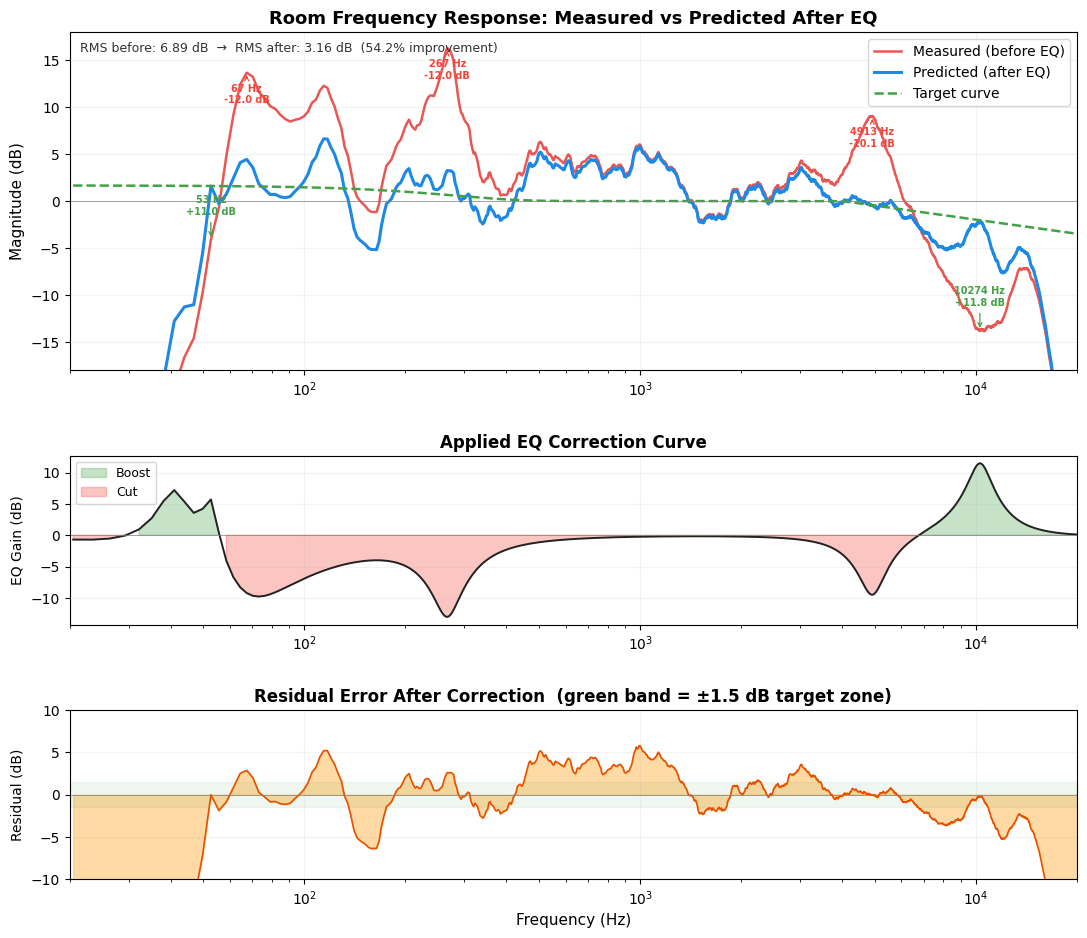


📊 50 Hz – 16 kHz  |  RMS before: 6.89 dB  →  after: 3.16 dB  |  improvement: 54.2%


In [20]:
mask = (freqs >= 20) & (freqs <= 20000)
mask_aud = (freqs >= 50) & (freqs <= 16000)

dev_before = smoothed[mask_aud] - target[mask_aud]
dev_after  = corrected[mask_aud] - target[mask_aud]
rms_before = np.sqrt(np.mean(dev_before**2))
rms_after  = np.sqrt(np.mean(dev_after**2))
improvement = (1 - rms_after/rms_before) * 100

fig = plt.figure(figsize=(13, 11))
gs = GridSpec(3, 1, height_ratios=[3, 1.5, 1.5], hspace=0.38)

# --- Top: before / after / target ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(freqs[mask], smoothed[mask],   color='#E53935', lw=1.8, alpha=0.85, label='Measured (before EQ)')
ax1.plot(freqs[mask], corrected[mask],  color='#1E88E5', lw=2.2, label='Predicted (after EQ)')
ax1.plot(freqs[mask], target[mask],     color='#43A047', lw=1.8, ls='--', label='Target curve')

for f in filters:
    idx = np.argmin(np.abs(freqs - f['frequency_hz']))
    col = '#F44336' if f['action']=='CUT' else '#43A047'
    ax1.annotate(f"{f['frequency_hz']:.0f} Hz\n{f['gain_db']:+.1f} dB",
        xy=(f['frequency_hz'], smoothed[idx]),
        fontsize=7, ha='center', color=col, fontweight='bold',
        xytext=(0, 18 if f['action']=='BOOST' else -22), textcoords='offset points',
        arrowprops=dict(arrowstyle='->', color=col, lw=0.9))

ax1.set_xscale('log'); ax1.set_xlim(20,20000); ax1.set_ylim(-18,18)
ax1.set_ylabel('Magnitude (dB)', fontsize=11)
ax1.set_title('Room Frequency Response: Measured vs Predicted After EQ', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.15); ax1.axhline(0, color='gray', lw=0.5)
ax1.text(0.01, 0.97, f'RMS before: {rms_before:.2f} dB  \u2192  RMS after: {rms_after:.2f} dB  ({improvement:.1f}% improvement)',
    transform=ax1.transAxes, fontsize=9, va='top', color='#333')

# --- Middle: correction curve ---
ax2 = fig.add_subplot(gs[1])
ax2.fill_between(freqs[mask], 0, correction_curve[mask],
    where=correction_curve[mask]>=0, color='#43A047', alpha=0.3, label='Boost')
ax2.fill_between(freqs[mask], 0, correction_curve[mask],
    where=correction_curve[mask]<0,  color='#F44336', alpha=0.3, label='Cut')
ax2.plot(freqs[mask], correction_curve[mask], color='#222', lw=1.4)
ax2.set_xscale('log'); ax2.set_xlim(20,20000); ax2.set_ylabel('EQ Gain (dB)', fontsize=10)
ax2.set_title('Applied EQ Correction Curve', fontweight='bold')
ax2.legend(fontsize=9); ax2.axhline(0, color='gray', lw=0.5); ax2.grid(True, alpha=0.15)

# --- Bottom: residual error ---
residual = corrected - target
ax3 = fig.add_subplot(gs[2])
ax3.fill_between(freqs[mask], 0, residual[mask], color='#FFB74D', alpha=0.5)
ax3.plot(freqs[mask], residual[mask], color='#E65100', lw=1.2)
ax3.axhspan(-1.5, 1.5, color='#43A047', alpha=0.08)
ax3.axhline(0, color='gray', lw=0.5)
ax3.set_xscale('log'); ax3.set_xlim(20,20000); ax3.set_ylim(-10,10)
ax3.set_xlabel('Frequency (Hz)', fontsize=11); ax3.set_ylabel('Residual (dB)', fontsize=10)
ax3.set_title('Residual Error After Correction  (green band = \u00b11.5 dB target zone)', fontweight='bold')
ax3.grid(True, alpha=0.15)

plt.show()
print(f"\n\U0001f4ca 50 Hz \u2013 16 kHz  |  RMS before: {rms_before:.2f} dB  \u2192  after: {rms_after:.2f} dB  |  improvement: {improvement:.1f}%")

## 8. Apply EQ to Sweep & Verification Measurement

In [21]:
def apply_eq_filters(audio, filters_list, sr=SAMPLE_RATE):
    """Apply parametric EQ as cascaded biquad IIR filters (RBJ cookbook)."""
    out = audio.copy().astype(np.float64)
    for f in filters_list:
        fc, gain, Q = f['frequency_hz'], f['gain_db'], f['Q']
        if abs(gain) < 0.05:
            continue
        A  = 10**(gain/40.0)
        w0 = 2*np.pi*fc/sr
        alpha = np.sin(w0)/(2*Q)
        b0 =  1 + alpha*A;  b1 = -2*np.cos(w0);  b2 = 1 - alpha*A
        a0 =  1 + alpha/A;  a1 = -2*np.cos(w0);  a2 = 1 - alpha/A
        b = [b0/a0, b1/a0, b2/a0]
        a = [1.0,   a1/a0, a2/a0]
        out = signal.lfilter(b, a, out)
    return out

# Apply EQ to the sweep
sweep_eq = apply_eq_filters(sweep, filters)

print("\u25b6 Running VERIFICATION measurement (sweep through EQ filters)...")

if USE_LIVE:
    try:
        recorded_verify = play_and_record(sweep_eq)
    except Exception as e:
        print(f"Audio error: {e} \u2014 using simulation for verification.")
        pre = np.zeros(int(0.5*SAMPLE_RATE))
        post = np.zeros(int(1.5*SAMPLE_RATE))
        recorded_verify = simulate_room_response(np.concatenate([pre, sweep_eq, post]))
else:
    pre = np.zeros(int(0.5*SAMPLE_RATE))
    post = np.zeros(int(1.5*SAMPLE_RATE))
    recorded_verify = simulate_room_response(np.concatenate([pre, sweep_eq, post]))

# Extract IR and frequency response from verification recording
ir_verify = extract_ir(recorded_verify, inv_filter)
freqs_v, raw_mag_v = compute_freq_response(ir_verify)
smoothed_verify = smooth_third_octave(freqs_v, raw_mag_v)

print("Verification measurement complete.")

▶ Running VERIFICATION measurement (sweep through EQ filters)...
▶ Playing & recording 7.0s ...
  ✅ Peak 0.221  (-13.1 dBFS)
IR: 24480 samples (510 ms)  |  peak at 5720.4 ms
Verification measurement complete.


## 9. Final Comparison: Before EQ / Predicted / Actual After EQ

RMS deviation  |  before EQ: 6.89 dB  |  predicted: 3.16 dB  |  actual: 5.68 dB


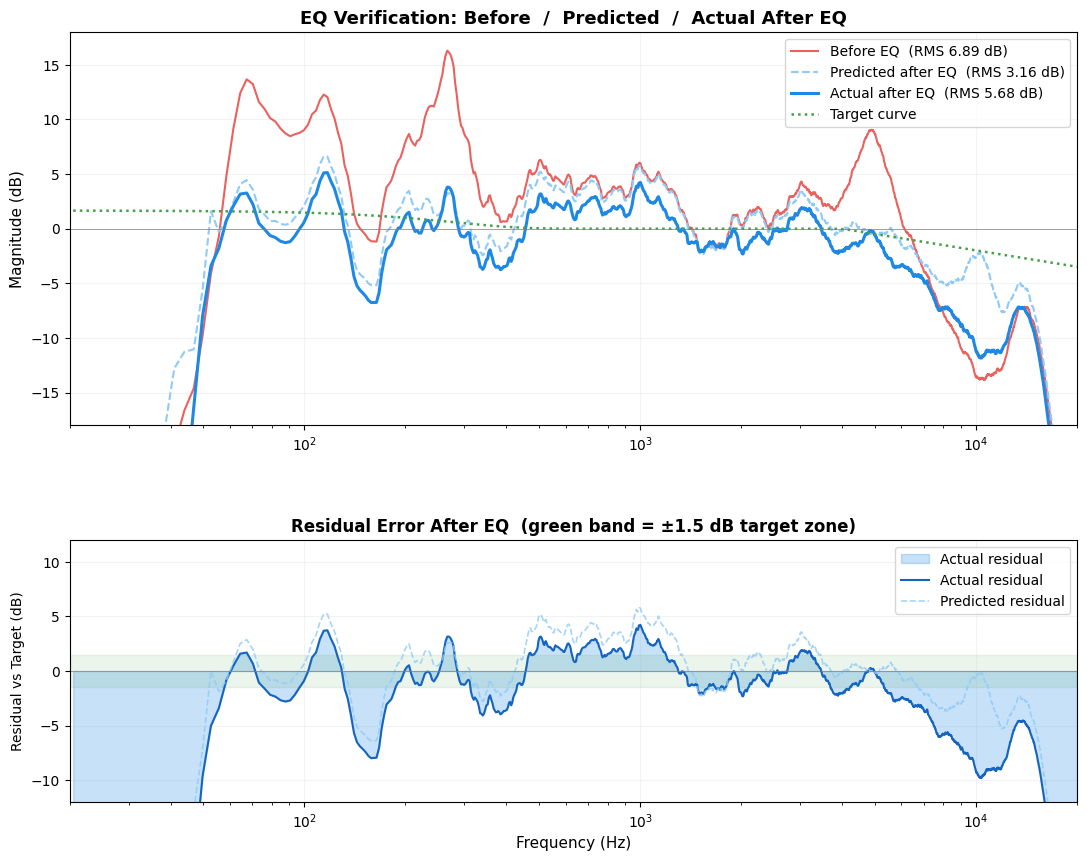


  EQ CALIBRATION RESULT
  Before EQ    RMS deviation : 6.89 dB
  Predicted    RMS deviation : 3.16 dB  (54.2% better)
  Actual       RMS deviation : 5.68 dB  (17.6% better)
  Prediction gap             : +2.52 dB  (EQ slightly over-corrected)


In [22]:
# Align target to the same frequency axis as verification (same n_fft -> same freqs)
target_v = make_target(freqs_v)

mask_v   = (freqs_v >= 20)  & (freqs_v <= 20000)
mask_aud_v = (freqs_v >= 50) & (freqs_v <= 16000)

dev_actual = smoothed_verify[mask_aud_v] - target_v[mask_aud_v]
rms_actual = np.sqrt(np.mean(dev_actual**2))
print(f"RMS deviation  |  before EQ: {rms_before:.2f} dB  |  predicted: {rms_after:.2f} dB  |  actual: {rms_actual:.2f} dB")

fig = plt.figure(figsize=(13, 10))
gs = GridSpec(2, 1, height_ratios=[3, 2], hspace=0.35)

# --- Top: three curves ---
ax1 = fig.add_subplot(gs[0])
ax1.plot(freqs[mask],   smoothed[mask],        color='#E53935', lw=1.5, alpha=0.8, label=f'Before EQ  (RMS {rms_before:.2f} dB)')
ax1.plot(freqs[mask],   corrected[mask],        color='#90CAF9', lw=1.5, ls='--',  label=f'Predicted after EQ  (RMS {rms_after:.2f} dB)')
ax1.plot(freqs_v[mask_v], smoothed_verify[mask_v], color='#1E88E5', lw=2.2,        label=f'Actual after EQ  (RMS {rms_actual:.2f} dB)')
ax1.plot(freqs[mask],   target[mask],           color='#43A047', lw=1.8, ls=':',   label='Target curve')

ax1.set_xscale('log'); ax1.set_xlim(20,20000); ax1.set_ylim(-18,18)
ax1.set_ylabel('Magnitude (dB)', fontsize=11)
ax1.set_title('EQ Verification: Before  /  Predicted  /  Actual After EQ', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.15); ax1.axhline(0, color='gray', lw=0.5)

# --- Bottom: residual comparison ---
ax2 = fig.add_subplot(gs[1])
residual_pred   = corrected[mask]      - target[mask]
residual_actual = smoothed_verify[mask_v] - target_v[mask_v]

ax2.fill_between(freqs_v[mask_v], 0, residual_actual, color='#1E88E5', alpha=0.25, label='Actual residual')
ax2.plot(freqs_v[mask_v],   residual_actual,   color='#1565C0', lw=1.5, label='Actual residual')
ax2.plot(freqs[mask],  residual_pred,    color='#90CAF9', lw=1.2, ls='--', label='Predicted residual', alpha=0.8)
ax2.axhspan(-1.5, 1.5, color='#43A047', alpha=0.10)
ax2.axhline(0, color='gray', lw=0.5)
ax2.set_xscale('log'); ax2.set_xlim(20,20000); ax2.set_ylim(-12,12)
ax2.set_xlabel('Frequency (Hz)', fontsize=11); ax2.set_ylabel('Residual vs Target (dB)', fontsize=10)
ax2.set_title('Residual Error After EQ  (green band = \u00b11.5 dB target zone)', fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.15)

plt.show()

print(f"\n{'='*60}")
print(f"  EQ CALIBRATION RESULT")
print(f"{'='*60}")
print(f"  Before EQ    RMS deviation : {rms_before:.2f} dB")
print(f"  Predicted    RMS deviation : {rms_after:.2f} dB  ({(1-rms_after/rms_before)*100:.1f}% better)")
print(f"  Actual       RMS deviation : {rms_actual:.2f} dB  ({(1-rms_actual/rms_before)*100:.1f}% better)")
gap = rms_actual - rms_after
print(f"  Prediction gap             : {gap:+.2f} dB  ({'EQ slightly over-corrected' if gap>0.5 else 'EQ slightly under-corrected' if gap<-0.5 else 'excellent match'})")

## 10. Music Playback: Room Coloring Snapshots

Play a real music file through the speakers, record it with the microphone, and compare the original file spectrum against the captured spectrum at configurable intervals.  
The difference reveals how the room + speaker system colors the sound — and can be compared against the sweep-based IR measured earlier.

In [23]:
!pip install soundfile -q   # for WAV/FLAC/OGG; for MP3 also: pip install librosa


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [33]:
import os

# ── CONFIGURATION ─────────────────────────────────────────────────────────────
MUSIC_FILE       = r"D:/Hudba/Midnight In Paris - A Collection Of French Jazz Lounge Classics [www.lokotorrents.com][mp3]/05. Atmosphere - Manu Dibango.mp3"  # ← change to your file
SEGMENT_START_S  = 30      # skip this many seconds at the start (avoid intros)
SEGMENT_DUR_S    = 20      # duration of each recorded snapshot  (seconds)
N_SEGMENTS       = 3       # how many snapshots to take
APPLY_EQ_FILTERS = True    # True  → play through the EQ filters computed above
                           # False → raw playback (shows unfiltered room coloring)
# ─────────────────────────────────────────────────────────────────────────────


# ── Helpers ───────────────────────────────────────────────────────────────────

def load_audio_file(path, target_sr=SAMPLE_RATE):
    """Load any audio file → mono float32 resampled to target_sr."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")

    # Try soundfile first (WAV, FLAC, OGG, AIFF …)
    try:
        import soundfile as sf
        audio, sr = sf.read(path, always_2d=True, dtype='float32')
        audio = audio.mean(axis=1)
    except Exception:
        # Fall back to librosa (MP3, AAC, … — needs ffmpeg)
        try:
            import librosa
            audio, sr = librosa.load(path, sr=None, mono=True, dtype=np.float32)
        except Exception as e:
            raise RuntimeError(
                f"Cannot open '{path}'.\n"
                "For WAV/FLAC: pip install soundfile\n"
                "For MP3:      pip install librosa  (also needs ffmpeg in PATH)\n"
                f"Original error: {e}"
            )

    # Normalize + headroom
    peak = np.max(np.abs(audio))
    if peak > 0:
        audio = (audio / peak * 0.70).astype(np.float32)

    # Resample if needed
    if sr != target_sr:
        from scipy.signal import resample_poly
        from math import gcd
        g = gcd(int(target_sr), int(sr))
        audio = resample_poly(audio, target_sr // g, sr // g).astype(np.float32)
        print(f"  Resampled {sr} Hz → {target_sr} Hz")

    dur = len(audio) / target_sr
    print(f"  Loaded: {os.path.basename(path)}  |  {dur:.1f}s")
    return audio


def welch_spectrum(audio, sr=SAMPLE_RATE):
    """Stable power spectrum via Welch method, smoothed to 1/3-octave (dB)."""
    nperseg = min(65536, len(audio) // 4)
    f, Pxx  = signal.welch(audio.astype(np.float64), fs=sr,
                            nperseg=nperseg, window='hann', scaling='density')
    mag_db  = 10 * np.log10(Pxx + 1e-14)
    mag_sm  = smooth_third_octave(f, mag_db)
    return f, mag_sm


def level_align(f, ref_db, meas_db, f_lo=800, f_hi=1200):
    """Shift meas_db so its mean in [f_lo, f_hi] matches ref_db (level-align)."""
    band = (f >= f_lo) & (f <= f_hi)
    if band.sum() > 0:
        meas_db = meas_db + (ref_db[band].mean() - meas_db[band].mean())
    return meas_db


# ── Load & slice ──────────────────────────────────────────────────────────────
print("Loading music file …")
music_full = load_audio_file(MUSIC_FILE)

seg_len      = int(SEGMENT_DUR_S    * SAMPLE_RATE)
start_smp    = int(SEGMENT_START_S  * SAMPLE_RATE)
total_needed = start_smp + N_SEGMENTS * seg_len

if len(music_full) < total_needed:
    raise ValueError(
        f"File too short ({len(music_full)/SAMPLE_RATE:.1f}s). "
        f"Need ≥ {total_needed/SAMPLE_RATE:.1f}s with current settings."
    )

# Original segments (for spectrum reference)
segments_orig = [
    music_full[start_smp + i*seg_len : start_smp + (i+1)*seg_len]
    for i in range(N_SEGMENTS)
]

# Playback segments (optionally EQ-filtered)
if APPLY_EQ_FILTERS and 'filters' in dir() and filters:
    print(f"  Applying {len(filters)} EQ filter(s) to playback …")
    segments_play = [apply_eq_filters(s, filters) for s in segments_orig]
    eq_label = "EQ-corrected"
else:
    segments_play = segments_orig
    eq_label = "Raw (no EQ)"

print(f"  {N_SEGMENTS} snapshot(s) × {SEGMENT_DUR_S}s  "
      f"starting at t={SEGMENT_START_S}s  [{eq_label}]")
print("Ready — run next cell to start playback & recording.")


Loading music file …
  Resampled 44100 Hz → 48000 Hz
  Loaded: 05. Atmosphere - Manu Dibango.mp3  |  206.3s
  Applying 6 EQ filter(s) to playback …
  3 snapshot(s) × 20s  starting at t=30s  [EQ-corrected]
Ready — run next cell to start playback & recording.


Starting 3 snapshot recording(s) …

  ▶  Snapshot 1/3  —  track 30s – 50s
▶ Playing & recording 20.6s ...
  ✅ Peak 0.071  (-22.9 dBFS)
  ▶  Snapshot 2/3  —  track 50s – 70s
▶ Playing & recording 20.6s ...
  ✅ Peak 0.069  (-23.2 dBFS)
  ▶  Snapshot 3/3  —  track 70s – 90s
▶ Playing & recording 20.6s ...
  ✅ Peak 0.067  (-23.5 dBFS)

All snapshots done.


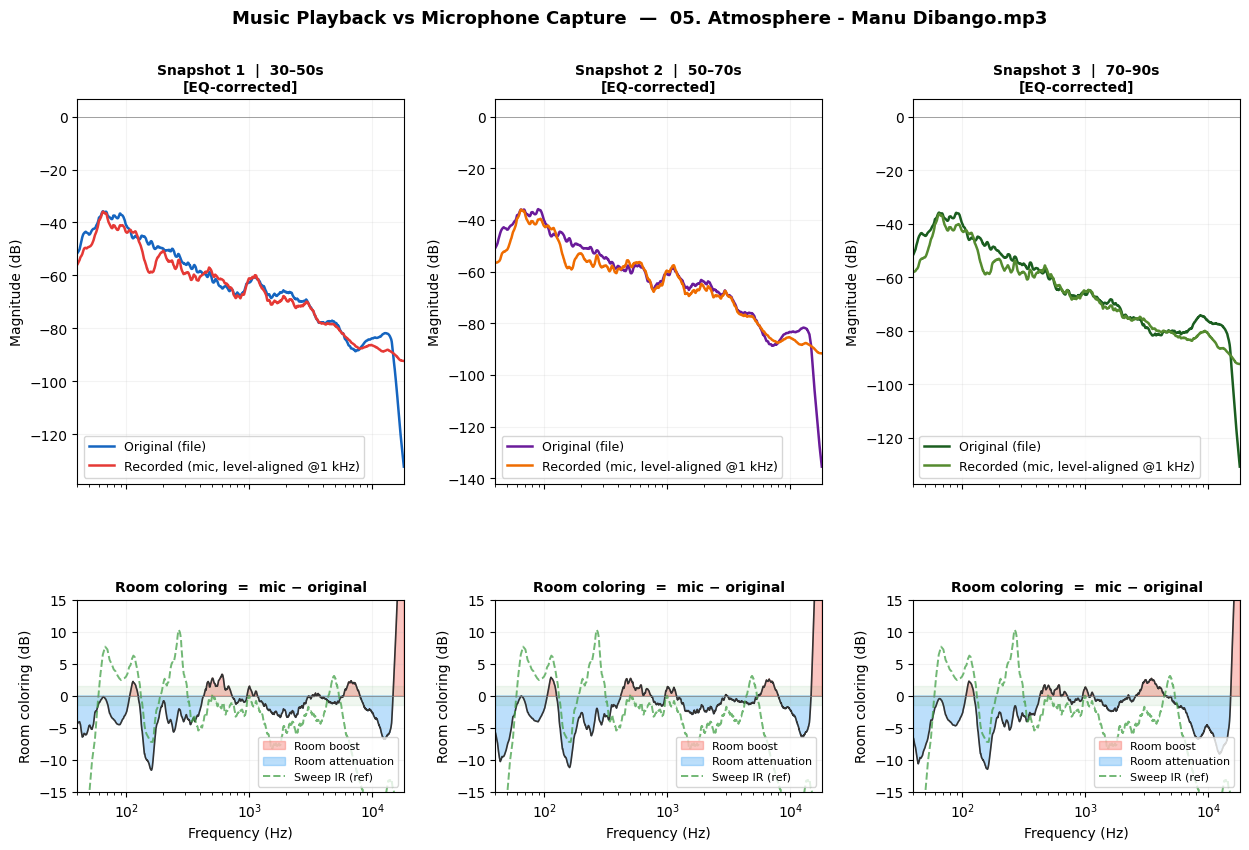

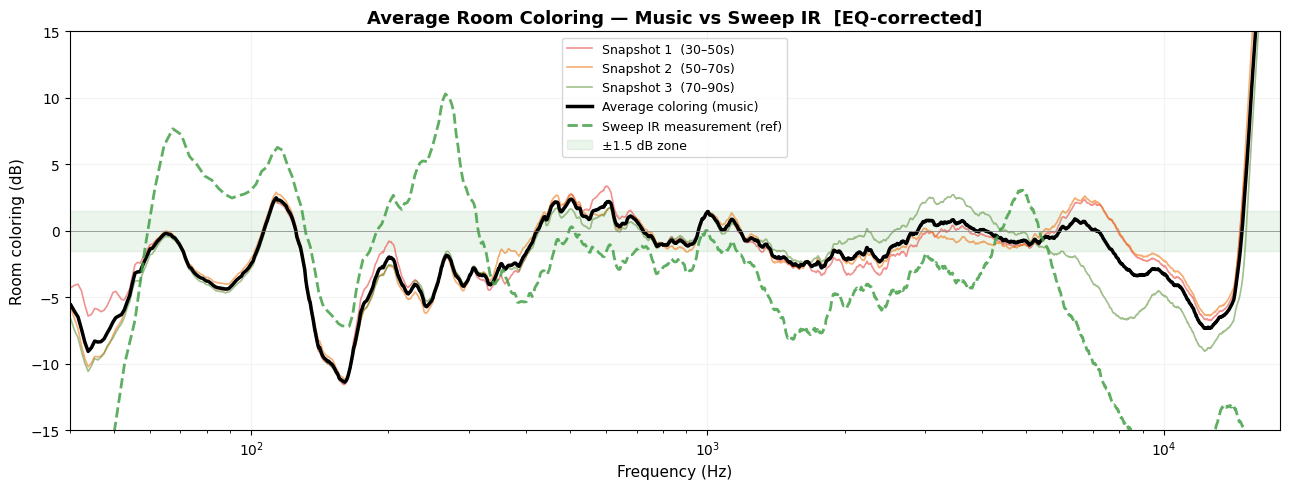


Average music-based room coloring RMS (40 Hz–18 kHz): 10.76 dB
(Lower = flatter room response; compare to sweep-based RMS above)


In [34]:
# ── Play & Record all snapshots ───────────────────────────────────────────────
pre_smp = int(0.3 * SAMPLE_RATE)   # 300 ms pre-silence added by play_and_record

print(f"Starting {N_SEGMENTS} snapshot recording(s) …\n")
recordings = []

for i, seg_play in enumerate(segments_play):
    t0 = SEGMENT_START_S + i * SEGMENT_DUR_S
    t1 = t0 + SEGMENT_DUR_S
    print(f"  ▶  Snapshot {i+1}/{N_SEGMENTS}  —  track {t0}s – {t1}s")

    rec = play_and_record(seg_play, pre_silence=0.3, post_silence=0.3)

    # Trim pre-silence so the recorded chunk aligns with segments_orig[i]
    rec_trim = rec[pre_smp : pre_smp + seg_len]
    if len(rec_trim) < seg_len:
        rec_trim = np.pad(rec_trim, (0, seg_len - len(rec_trim)))
    recordings.append(rec_trim)

print("\nAll snapshots done.")


# ── Compute spectra for every snapshot ───────────────────────────────────────
snap_data = []   # list of dicts with f, spec_orig, spec_rec_al, coloring

for i in range(N_SEGMENTS):
    f_o, sp_orig = welch_spectrum(segments_orig[i])
    f_r, sp_rec  = welch_spectrum(recordings[i])
    # Both have the same frequency axis (same sr & nperseg)
    sp_rec_al    = level_align(f_o, sp_orig, sp_rec)
    coloring     = sp_rec_al - sp_orig
    snap_data.append(dict(f=f_o, orig=sp_orig, rec=sp_rec_al, coloring=coloring))


# ── Per-snapshot figure: original / recorded / room coloring ─────────────────
COLORS_ORIG = ['#1565C0', '#6A1B9A', '#1B5E20']
COLORS_REC  = ['#E53935', '#EF6C00', '#558B2F']

fig, axes = plt.subplots(
    2, N_SEGMENTS,
    figsize=(max(6, 5 * N_SEGMENTS), 9),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.40, 'wspace': 0.28}
)
if N_SEGMENTS == 1:
    axes = axes.reshape(2, 1)

# Sweep-based room curve for reference (already in dB relative to 1 kHz)
sweep_ref_f   = freqs
sweep_ref_mag = smoothed - np.interp(1000, freqs, smoothed)   # zero at 1 kHz

for i, sd_i in enumerate(snap_data):
    f     = sd_i['f']
    m     = (f >= 40) & (f <= 18000)
    t0    = SEGMENT_START_S + i * SEGMENT_DUR_S

    # — top: original vs recorded —
    ax_t = axes[0, i]
    ax_t.plot(f[m], sd_i['orig'][m], color=COLORS_ORIG[i % 3], lw=1.8,
              label='Original (file)')
    ax_t.plot(f[m], sd_i['rec'][m],  color=COLORS_REC[i % 3],  lw=1.8,
              label='Recorded (mic, level-aligned @1 kHz)')
    ax_t.set_xscale('log'); ax_t.set_xlim(40, 18000)
    ax_t.set_ylabel('Magnitude (dB)'); ax_t.grid(True, alpha=0.15)
    ax_t.set_title(
        f"Snapshot {i+1}  |  {t0}–{t0+SEGMENT_DUR_S}s\n[{eq_label}]",
        fontweight='bold', fontsize=10
    )
    ax_t.legend(fontsize=9); ax_t.axhline(0, color='gray', lw=0.5)

    # — bottom: room coloring vs sweep IR —
    ax_b = axes[1, i]
    col  = sd_i['coloring']
    ax_b.fill_between(f[m], 0, col[m],
        where=col[m] >= 0, color='#F44336', alpha=0.30, label='Room boost')
    ax_b.fill_between(f[m], 0, col[m],
        where=col[m] <  0, color='#2196F3', alpha=0.30, label='Room attenuation')
    ax_b.plot(f[m], col[m], color='#333', lw=1.2)
    # Sweep-IR overlay
    ax_b.plot(sweep_ref_f, sweep_ref_mag, color='#43A047', lw=1.4,
              ls='--', alpha=0.75, label='Sweep IR (ref)')
    ax_b.axhline(0, color='gray', lw=0.5)
    ax_b.axhspan(-1.5, 1.5, color='#43A047', alpha=0.08)
    ax_b.set_xscale('log'); ax_b.set_xlim(40, 18000); ax_b.set_ylim(-15, 15)
    ax_b.set_xlabel('Frequency (Hz)'); ax_b.set_ylabel('Room coloring (dB)')
    ax_b.set_title('Room coloring  =  mic − original', fontweight='bold', fontsize=10)
    ax_b.legend(fontsize=8, loc='lower right'); ax_b.grid(True, alpha=0.15)

fig.suptitle(
    f'Music Playback vs Microphone Capture  —  {os.path.basename(MUSIC_FILE)}',
    fontsize=13, fontweight='bold'
)
plt.show()


# ── Summary: average room coloring across all snapshots ───────────────────────
fig2, ax = plt.subplots(figsize=(13, 5))

all_coloring = np.vstack([sd_i['coloring'] for sd_i in snap_data])
f_common     = snap_data[0]['f']
m_sum        = (f_common >= 40) & (f_common <= 18000)

for i, sd_i in enumerate(snap_data):
    t0 = SEGMENT_START_S + i * SEGMENT_DUR_S
    ax.plot(f_common[m_sum], sd_i['coloring'][m_sum],
            color=COLORS_REC[i % 3], lw=1.2, alpha=0.55,
            label=f'Snapshot {i+1}  ({t0}–{t0+SEGMENT_DUR_S}s)')

avg_col = all_coloring.mean(axis=0)
ax.plot(f_common[m_sum], avg_col[m_sum], color='black', lw=2.5,
        label='Average coloring (music)')
ax.plot(sweep_ref_f, sweep_ref_mag, color='#43A047', lw=2.0,
        ls='--', alpha=0.85, label='Sweep IR measurement (ref)')

ax.axhline(0, color='gray', lw=0.5)
ax.axhspan(-1.5, 1.5, color='#43A047', alpha=0.10, label='±1.5 dB zone')
ax.set_xscale('log'); ax.set_xlim(40, 18000); ax.set_ylim(-15, 15)
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Room coloring (dB)', fontsize=11)
ax.set_title(
    f'Average Room Coloring — Music vs Sweep IR  [{eq_label}]',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=9); ax.grid(True, alpha=0.15)
plt.tight_layout(); plt.show()

rms_col = np.sqrt(np.mean(avg_col[m_sum]**2))
print(f"\nAverage music-based room coloring RMS (40 Hz–18 kHz): {rms_col:.2f} dB")
print("(Lower = flatter room response; compare to sweep-based RMS above)")
